- 군집화의 개념과 기본 과정
- 거리 / 유사도 정의와 측정 방법
- 주성분 분석(PCA)의 목적
- 4가지 군집화 알고리즘의 특징과 과정
    - 계층적 군집화
    - k-means
    - DBSCAN
    - GMM
- 군집화 평가 방법 (실루엣 계수, 던 인덱스)

# 군집화

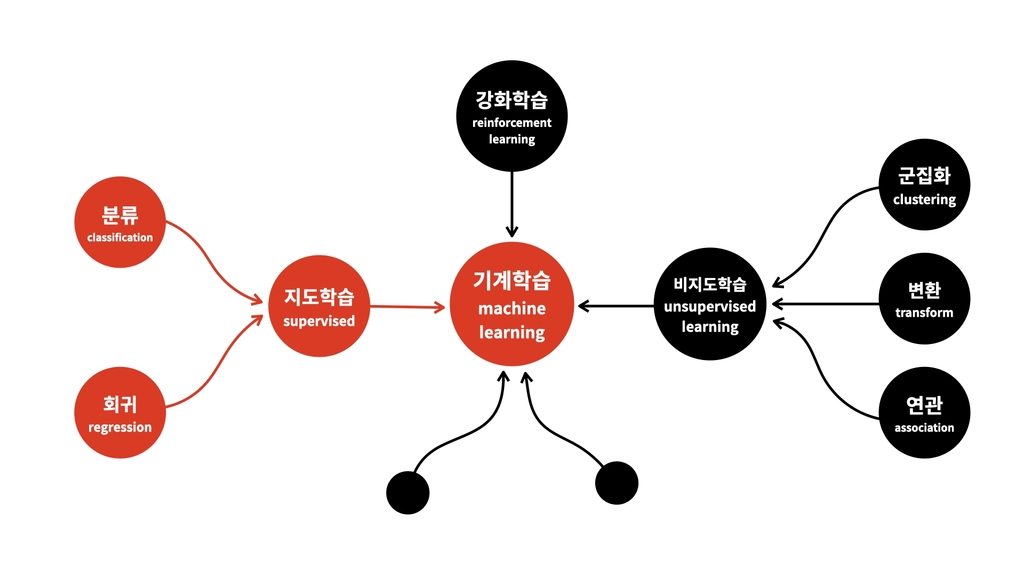

## 들어가기 전에 ...

### 머신러닝
_인공지능의 한 분야로, 컴퓨터가 스스로 학습할 수 있도록 도와주는 알고리즘이나 기술을 개발하는 분야. 크게 지도학습과 비지도학습으로 구분됨_


## 군집화란?

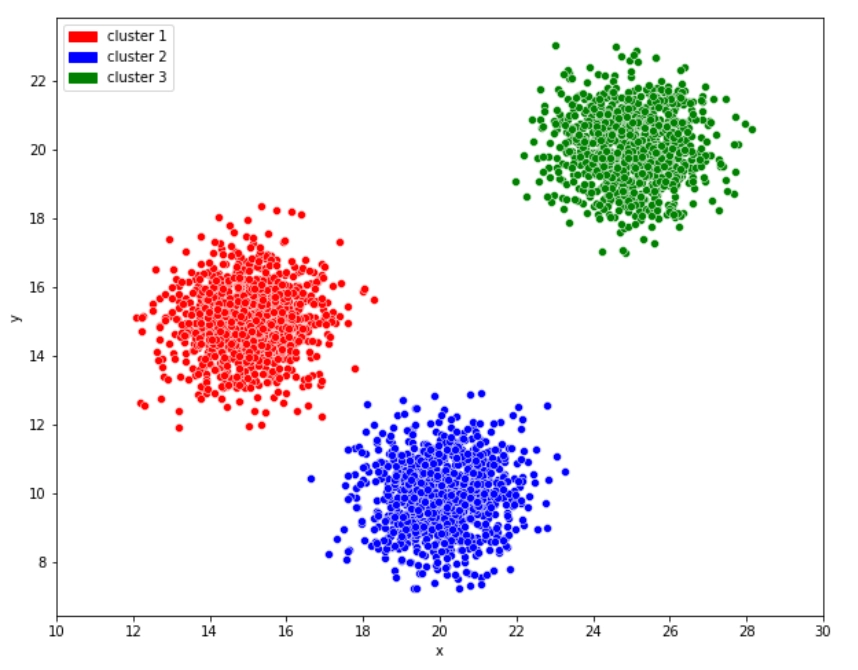

데이터를 비슷한 특성을 가진 그룹(군집)으로 나누는 비지도 학습 기법. <BR>
→ 각 그룹이 어떻게 구성되어있는지 파악하면서 전체 데이터 구조를 이해할 수 있음. <BR>
→ 사전에 정해진 목표 없이 데이터셋에 존재하는 고유한 패턴을 발견하고 추출하기 때문에 비지도 학습으로 분류됨.

## 군집화의 목표
1. 응집도 최대화: 같은 군집에 속하는 데이터끼리는 최대한 비슷하도록 함.
2. 분리도 최대화: 서로 다른 군집은 최대한 분리되도록 함.

### 군집화 과정

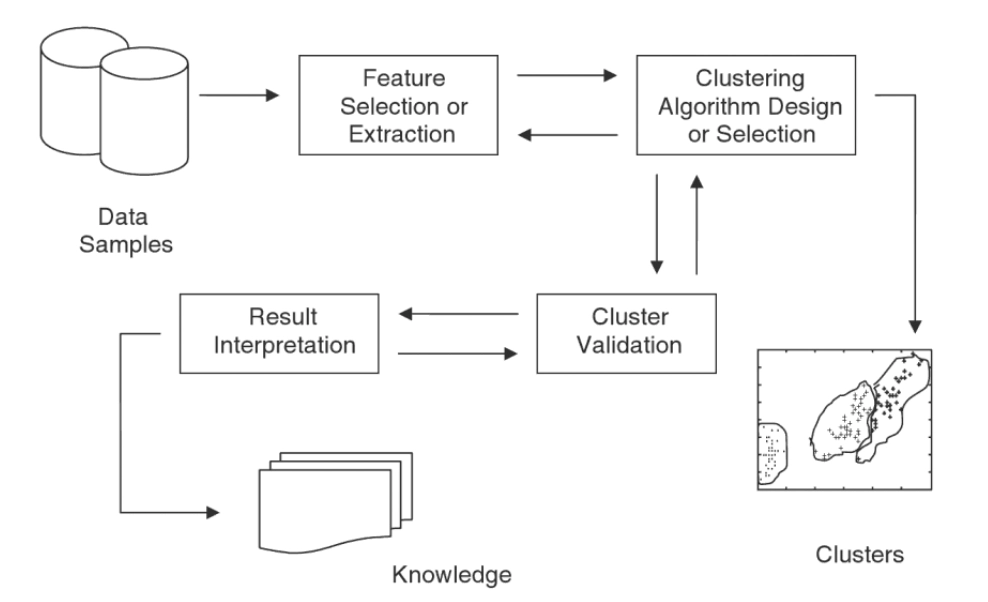

1. **피처 선택 또는 추출** — 군집화에 사용할 데이터의 피처(특징)을 선택
2. **군집화 알고리즘 선택** — 데이터의 특성과 목표에 따라 적합한 알고리즘을 선택
3. **군집 유효성 검증** — 군집화가 얼마나 잘 되었는지 평가
4. **결과 해석** — 각 군집이 지닌 특성 분석 및 해석

## 군집화를 위한 데이터 준비(1. 피처 선택)

### 군집화 주요 고려사항

1. **변수 유형 이해**
    - 군집화에 사용될 피처의 종류와 특성을 명확하게 이해해야 함
    - 변수 종류가 연속형 또는 명목형인지에 따라 적합한 군집화 알고리즘이 달라짐

2. **거리 / 유사도 정의와 측정**
    - 군집화는 데이터 간의 **거리(distance)** 또는 **유사도(similarity)**를 기반으로 그룹을 형성
    - 변수 유형에 따라 적합한 거리 측정 방식이 다르기 때문에 정의가 중요

3. **차원 축소**
    - 변수가 많아질수록 모델이 복잡해지고, 효율성과 성능이 떨어짐
    - 유사한 변수를 통합하거나 필요 없는 변수를 제거해 변수 개수를 줄일 수 있음

#### 변수 유형 이해

| 유형 | 예시 | 거리 측정 | 알고리즘 |
| --- | --- | --- | --- |
| **연속형** | 키, 몸무게, 나이, 소득 | 유클리디안, 맨하탄 | k-means, 계층적 군집화 |
| 명목형 | 성별, 지역, 직업 | 해밍, 자카드 | K-modes, 계층적 군집화 |
| 혼합형 | 연속형 + 명목형 | Gower distance | K-prototypes, 계층적 군집화 |


#### 거리 / 유사도 정의와 측정

데이터의 거리 측정 방법: 군집화에서 데이터 포인트나 군집 간의 유사성/비유사성을 수치로 계산하는 방법들. 거리가 가까울수록 유사하고, 멀수록 다르다고 판단.

**1. 유클리디안 거리 (Euclidean Distance)**

$$
d(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{i=1}^n (x_i - y_i)^2}
$$

- **가장 일반적**인 거리 측정 방법
- 직선거리를 의미하며, K-means에서 기본적으로 사용

---

**2. 맨하탄 거리 (Manhattan Distance)**

$$
d(\mathbf{x}, \mathbf{y}) = \sum_{i=1}^n |x_i - y_i|
$$

- 각 차원의 차이의 절댓값의 합
- **이상치에 덜 민감**한 특징
- 참고) 유클리디안 거리 vs 맨하탄 거리
    
    !image-4.png
    

---

**3. 코사인 유사도 (Cosine Similarity)**

$$
\text{similarity} = \frac{\mathbf{x} \cdot \mathbf{y}}{||\mathbf{x}|| \times ||\mathbf{y}||}
$$

- 벡터 간의 **각도**를 측정
- 텍스트 데이터나 고차원 데이터에 효과적

#### 차원 축소

**차원의 저주**: 피처 공간이 너무 커서 알고리즘이 데이터를 효과적/효율적으로 훈련할 수 없는 현상

→ **차원 축소 과정 필요**

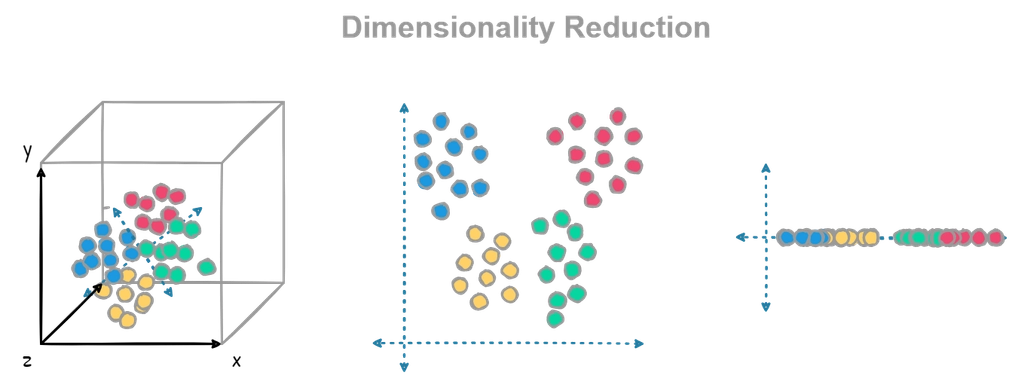

목표: 고차원 데이터를 저차원 공간에 투영하면서도 핵심 정보는 가능한 지켜내는 것 <BR>
→ 노이즈를 줄여 패턴 학습에 유리해짐

1. 선형 투영 : 고차원 공간에서 저차원 공간으로 선형적으로 데이터를 투영 <BR>
ex. 주성분 분석(PCA), 특잇값 분해(SVD), 랜덤 투영 등
2. 매니폴드 학습(비선형 차원 축소) : 유클리드 거리가 아닌 데이터 포인트들 사이의 곡선 거리를 고려하며 학습 <BR>
ex. t-SNE, UMAP, Isomap 등

#### PCA(Principal Component Analysis)

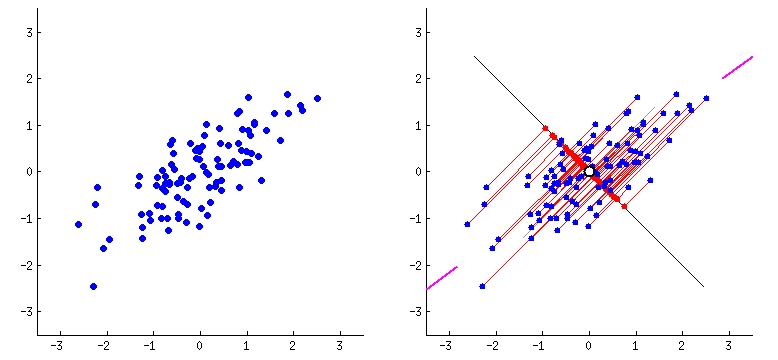

PCA 핵심 목적: 
다차원 데이터에서 가장 정보량(분산)이 큰 방향을 찾고, 그 방향을 기준으로 데이터를 투영하여 차원을 줄이는 것

- 데이터의 **분산을 최대한 보존**하면서 차원을 줄임
- 상관관계가 높은 피처들을 결합해, 상관관계가 없는 더 적은 수의 피처로 데이터를 표현
- 원본의 고차원 데이터에서 최대 분산 방향을 찾아 상관관계를 감소시키고, 저차원에 공간에 이들을 투영하는것

##### [코드 실습]

``` python
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_scaled = StandardScaler().fit_transform(X)   # ①
pca = PCA().fit(X_scaled)                      # ②
print(pca.explained_variance_ratio_)           # ③

```

| 줄 | 이 줄이 하는 일 | 왜 필요한가 |
| --- | --- | --- |
| ① | 모든 피처를 평균 0, 분산 1로 맞춤 | PCA는 **분산이 큰 방향**을 찾는데, 스케일을 안 맞추면 단위가 큰 변수가 무조건 1등이 됨 |
| ② | `n_components` 없이 학습 → 주성분을 전부 구함 | 몇 개를 쓸지 **아직 모르므로** 일단 다 뽑아보는 것 |
| ③ | 각 주성분이 설명하는 분산 비율을 출력 | 이 숫자를 보고 **몇 개를 쓸지 결정** |

##### PCA 주의사항

1. **표준화 필수** : PCA 사용 전 반드시 데이터 표준화 수행
2. **결측값 처리** : 결측값이 있으면 사용 불가
3. **해석의 어려움** : 주성분은 원본 특성들의 조합이라 직관적 해석이 어려움
4. **정보 손실** : 차원축소 과정에서 일부 정보가 손실됨

## 군집화 알고리즘(2. 알고리즘 선택)

### 계층적 군집화

_가장 가까운 것부터 둘씩 차례로 합쳐 나가면서, 무엇이 언제 뭉쳤는지를 나무 모양(덴드로그램)으로 기록하는 군집화 방법_ <BR>

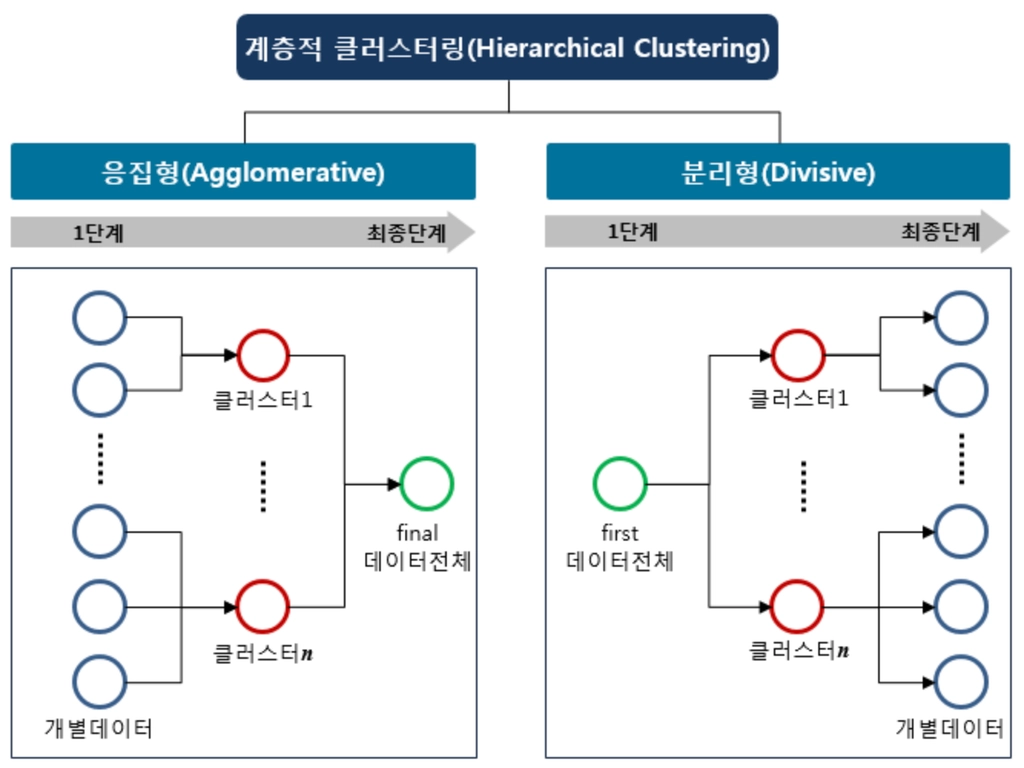

#### 1. 응집형 클러스터링 <BR>
: 각 샘플이 독립적인 클러스터로 시작. 하나만 남을 때까지 가장 가까운 클러스터를 병합

##### [과정]

1. **거리 행렬 계산**: 모든 데이터 포인트 간의 거리를 계산
2. **단일 클러스터 시작**: 각 데이터 포인트를 개별 클러스터로 초기화
3. **가장 가까운 클러스터 병합**: 정의된 기준에 따라 가장 가까운 두 클러스터를 병합
4. **거리 행렬 업데이트**: 새 클러스터와 나머지 간 거리를 다시 계산
5. **반복**: 모두 하나의 클러스터가 될 때까지 3, 4를 반복

#### 2. 분할형 클러스터링 <BR>
: 전체를 포함하는 하나의 클러스터에서 시작해, 유사성이 낮은 데이터를 더 작은 클러스터로 나눔

### 연결 방법
_계층적 군집화에서 두 군집 간의 거리를 계산하는 방식_ <BR>

1. **Single linkage (단일 연결법 / 최단 연결법)**

> **군집 A와 B 사이의 가장 가까운 두 점 간 거리**로 군집 간 거리를 정의.
> 
- **고립된 군집**을 찾는데 중점
- 이상치에 취약함
    - (참고) 이상치에 취약한 이유
        
        이상치가 한 클러스터에 속하면 해당 클러스터와 가장 가까운 다른 클러스터와도 가까운 거리에 있게 됨. 이는 연쇄적으로 다른 클러스터들도 잘못된 클러스터링을 유발할 수 있음.
        
    
    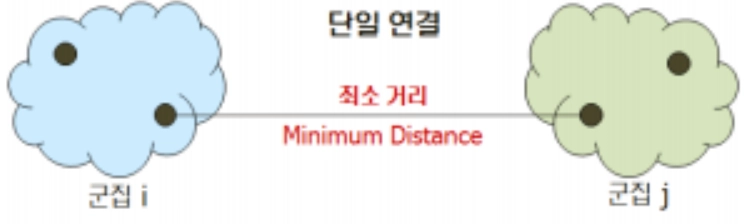
    


2. **Complete linkage (완전 연결법 / 최장 연결법)**

> **군집 A와 B 사이의 가장 먼 두 점 간 거리**로 군집 간 거리 정의.
> 
- **군집들의 내부 응집성**에 중점을 둔 방법
- 최단 연결법과 마찬가지로 이상치에 민감함

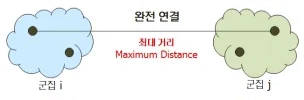



3. **Average linkage (평균 연결법)**

> **군집 A와 B의 모든 점 쌍 사이 거리의 평균.**
> 
- **모든 항목에 대한 거리 평균**을 구함
- 최단·최장 연결법보다 이상치에 덜 민감
- 계산량이 많아질 수 있다는 단점

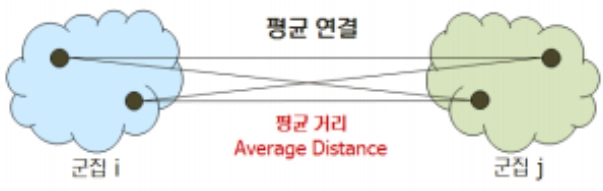



4. **Centroid Method (중심 연결법)**

> 각 군집의 **중심점(centroid)** 간의 거리.
> 
- 두 군집의 **중심 간의 거리를 측정**
- 중심을 계산해야 하므로 시간이 오래 걸림
- 덴드로그램에서 거리 축이 줄어드는 **inversion**이 발생할 수 있음

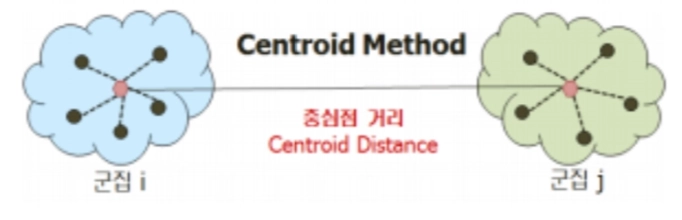



5. **Median (중앙 연결법)**

> 두 군집의 **중앙값** 사이의 거리
> 
- 두 군집의 중심점 사이 **산술적 중간 지점을 새로운 대표값으로 설정**
- 극단값에 영향을 덜 받음
- 기하학적 구조를 파악하기는 어려움
- 중심 연결법 vs 중앙 연결법
    
    이름 때문에 비슷해 보이지만 차이가 있습니다.
    
    중심 연결법은 새 군집이 형성되면 그 안의 **모든 개별 데이터 포인트의 산술 평균**을 다시 계산해 중심점을 정하는 반면,
    
    중앙 연결법은 데이터가 몇 개든 무시하고 **기존 두 군집 중심점 사이의 딱 중간 지점**을 대표점으로 정합니다.
    
    | 구분 | 중심 연결법 (Centroid) | 중앙 연결법 (Median) |
    | --- | --- | --- |
    | **기준점 업데이트** | 군집 내 **모든 점**의 평균 | 두 군집 **중심점 간**의 중점 |
    | **가중치** | 데이터 개수에 비례 | 군집별로 동일하게 부여 |
    | **시각적 결과** | 큰 군집 쪽으로 중심이 이동 | 두 군집의 정중앙에 중심이 위치 |
    
 
6. **Ward's Procedure (Ward 연결법)**

> 군집 내 제곱합(SSE)이 **가장 적게 증가**하도록 병합.
> 
- 병합 후 군집 내 **SSE 증가분이 최소**인 것을 선택
- 실무에서 가장 무난하게 쓰이는 기본값

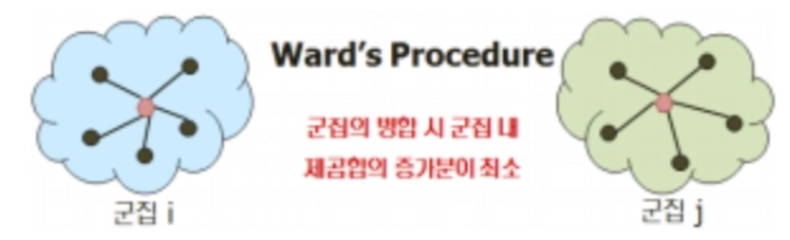

<aside>
📌

**연결 방법별 거리 계산 기준 요약**

---

- **`single`**: 두 군집 간 가장 가까운 점들 사이의 거리
- **`complete`**: 두 군집 간 가장 먼 점들 사이의 거리
- **`average`**: 두 군집의 모든 점들 간 평균 거리
- **`centroid`**: 두 군집의 중심점 사이의 거리
- **`median`**: 두 군집의 중앙값 사이의 거리
- **`ward`**: 군집 내 분산을 최소화하는 방향으로 병합
</aside>

##### [코드 실습]

``` python

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

Z = linkage(X_scaled, method='ward')               # ①
dendrogram(Z)                                      # ②
labels = fcluster(Z, t=2, criterion='maxclust')    # ③

```

| 줄 | 이 줄이 하는 일 | 왜 필요한가 |
| --- | --- | --- |
| ① | 병합 기록을 통째로 계산 (누가 누구와 어느 높이에서 합쳤는지) | `method`가 바로 위에서 배운 **연결 방법** — 6가지 중 하나를 고르는 자리 |
| ② | 그 기록을 나무 그림으로 그림 | **보고 나서** 몇 개로 자를지 정하기 위해 |
| ③ | 2개 군집이 되도록 잘라서 레이블을 뽑음 | **여기서야 비로소 k를 정합니다.** ①을 다시 돌릴 필요가 없음 |

#### [계층적 군집화의 장단점]

- **장점** <BR> 
    - **k를 미리 정하지 않아도 됨** — 그려놓고 나중에 자름
    - **데이터의 구조 전체가 눈에 보임** — 어느 군집 안에 어떤 하위 군집이 있는지까지
    - 거리만 정의되면 **어떤 유형의 데이터에도** 적용 가능 (2-2 참고)
    - 결과가 **항상 같음** — 랜덤 초기화가 없어서 `random_state`가 필요 없음

- **단점**
    - **느리고 메모리를 많이 먹음** — 거리 행렬 때문에 수만 건 이상은 사실상 불가 (2-2 토글 참고)
    - **한 번 합치면 되돌릴 수 없음** — 앞에서 잘못 합쳤어도 끝까지 그대로 감
    - 이상치에 민감 (특히 단일·완전 연결법)
    - 자르는 높이를 결국 **사람이 눈으로 정해야 함**

### k-means

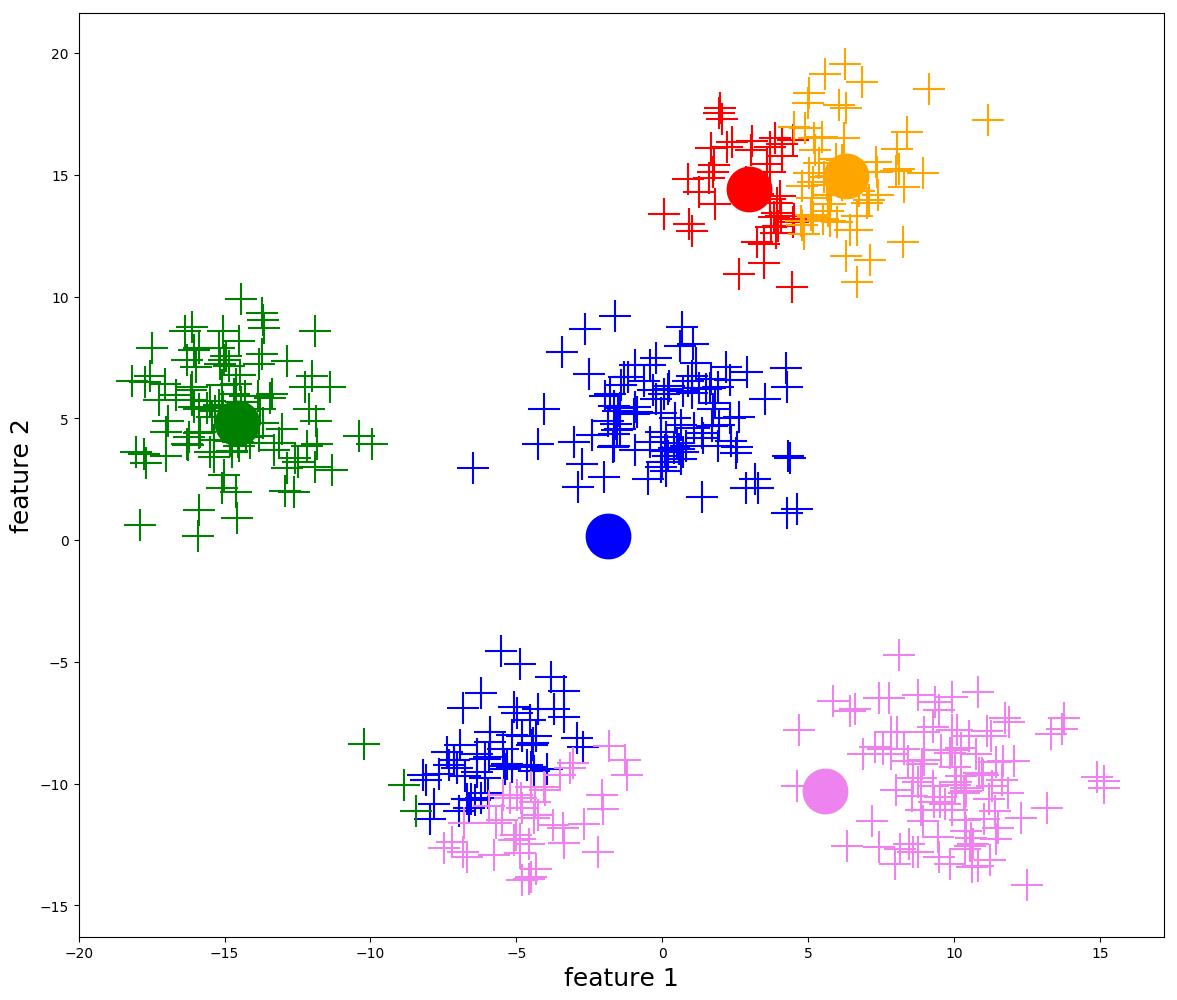 <BR>

_데이터를 정해진 개수(K)의 그룹으로 나누되, 각 그룹의 중심점(centroid)과의 거리가 가장 가까운 데이터끼리 묶는 군집화 알고리즘_ <BR>

- 군집화에서 가장 일반적으로 사용되는 알고리즘
- 중심점(centroid)을 선택해, 그 **중심에 가장 가까운 데이터**들을 묶어나가는 기법
- 군집을 **중심점 하나로 대표** <BR>
→ 중심(평균)을 구할 수 없는 데이터에는 쓸 수 없음

#### [k-means 주요 단계]

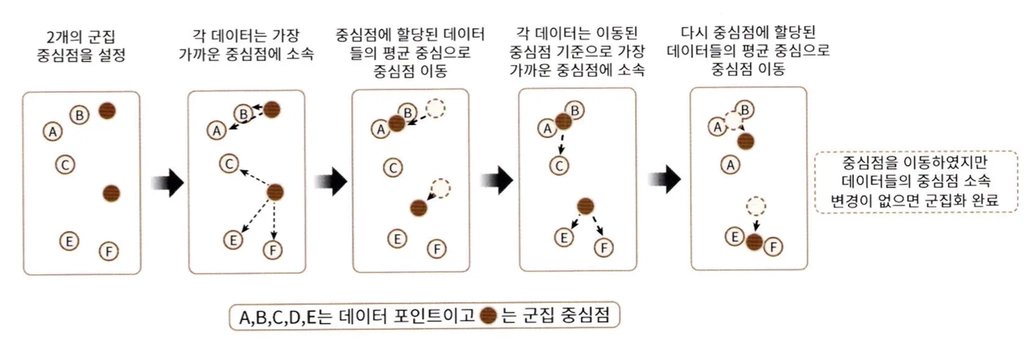

1. 데이터 표본들 중에서 랜덤하게 $k$개의 중심점(centroid)을 초기 클러스터 중심으로 선택
2. 각 표본들을 가장 가까운 중심점 $\mu^{(j)}, j \in \{ 1, …, k \}$에 할당
3. 각 클러스터에 할당된 표본들의 평균을 계산하여 중심점을 이동
4. 클러스터 할당이 변하지 않거나 최대 반복 횟수(`max_iter`)에 도달할 때까지 2, 3을 반복

#### [코드 실습]

```python
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3,          # ①
                init='k-means++',      # ②
                n_init=10,             # ③
                random_state=42)       # ④
labels = kmeans.fit_predict(X_scaled)  # ⑤
```

| 줄 | 이 줄이 하는 일 | 왜 필요한가 |
| --- | --- | --- |
| ① | 군집을 3개로 나누라고 지정 | k-means는 **k를 사람이 정해줘야** 함. 이걸 어떻게 정하는지가 아래 엘보우 방법 |
| ② | 초기 중심점을 서로 멀리 떨어뜨려 배치 | 랜덤으로 두면 **초기 위치에 따라 결과가 바뀜**. 이 문제를 줄이는 개선판 |
| ③ | 서로 다른 초기값으로 10번 돌려 가장 좋은 것 채택 | 그래도 남는 초기값 운을 **반복으로** 줄임 |
| ④ | 난수 시드 고정 | 고정하지 않으면 **돌릴 때마다 결과가 달라져** 과제·발표에서 재현이 안 됨 |
| ⑤ | 학습 후 각 데이터가 몇 번 군집인지 배열로 반환 | `[0,2,1,0,...]` — 이게 군집화의 **최종 산출물** |

#### [ k-means의 장단점 ]

- **장점**
    - 직관적이고 구현이 쉬움
    - 대용량 데이터에도 적용 가능
- **단점**
    - **초기 centroid에 민감** → `k-means++`로 완화 (위 코드 ②)
    - **군집 수 k 결정이 어려움** → 엘보우 방법, 실루엣 계수로 탐색
    - **아웃라이어에 민감** : 평균 기반이라 **이상치 하나가 중심을 왜곡**
    - **기하학적인 모양의 군집은 파악하기 어려움** → 길쭉하거나 초승달 모양이면 실패

### 엘보우 방법

_클러스터 내 SSE를 바탕으로 그래프를 활용해 최적 클러스터 개수 k를 추정하는 방법_

#### [엘보우 방법 장단점]

- **장점** : 직관적이고 구현이 간단
- **단점** : 그래프가 완만하면 **팔꿈치가 어디인지 주관이 개입**. 데이터에 따라 아예 안 보이기도 함

### DBSCAN

_밀도가 높은 지역의 데이터를 하나의 군집으로 묶고, 밀도 기준을 만족하지 못하는 점은 군집에 포함시키지 않는 군집화 알고리즘_

#### [ DBSCAN의 특징 ]

- 명시적으로 이상치를 지정하여 클러스터링에서 제외
- 다른 알고리즘 대비 이상치로부터 자유로움
- 어떤 데이터가 여러 군집의 특정 거리 내에 있으면 가장 밀도가 높은 군집과 그룹화

#### [ DBSCAN 알고리즘의 주요 단계 ]

**1단계: 샘플 분류**

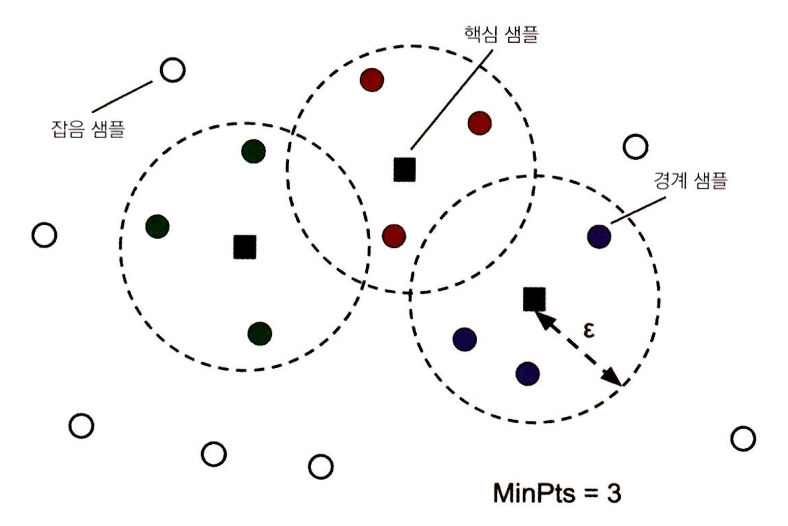

- **핵심 샘플 (Core Point)** — 반경 ε 안의 이웃이 지정된 개수(MinPts) 이상
- **경계 샘플 (Border Point)** — ε 이내 이웃은 부족하지만, 다른 핵심 샘플의 ε 안에 있음
- **잡음 샘플 (Noise Point)** — 위 둘 다 아닌 나머지 전부

#### [코드 실습]

```python
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5,          # ①
            min_samples=5)    # ②
labels = db.fit_predict(X_scaled)
print((labels == -1).sum())   # ③
```

| 줄 | 이 줄이 하는 일 | 왜 필요한가 |
| --- | --- | --- |
| ① | 두 점이 이웃이 되기 위한 최대 거리 | **너무 작으면** 대부분이 이상치로 빠지고, **너무 크면** 전부 한 덩어리가 됨 |
| ② | 군집으로 인정하기 위한 ε 내 최소 점 개수 | 이 수를 못 채우면 군집이 아니라 **잡음**으로 분류 |
| ③ | 레이블이 `-1`인 개수를 셈 | DBSCAN은 이상치에 **`-1`**을 붙임. **k-means에는 없는 출력** — 이 숫자가 곧 탐지된 이상치 수 |

#### [ DBSCAN의 장단점 ]

- **장점**
    - 클러스터 모양을 원형으로 가정하지 않음 → **임의의 기하학적 분포**도 잘 처리
    - **이상치에 민감하지 않음** : Noise를 통해 **Outlier 검출이 가능**
    - 모든 샘플을 클러스터에 할당하지 않음
            
- **단점**
    - `eps`와 `min_samples` 설정에 많은 영향을 받음 (조절에 도메인 지식 필요)
    - 연산량이 많아 속도가 느림
    - **밀도가 서로 다른** 군집들은 잘 잡지 못함
        
        → 밀도가 높은 곳에 집중하다 보니, 밀도가 낮은 쪽을 통째로 **noise로 버림**
        
    - **차원의 저주**의 영향을 받음

### Gaussian Mixture Model (GMM)

_데이터가 여러 다른 모양의 가우시안 분포로 구성되었다고 가정하고, 각 분포를 클러스터로 인식하는 군집화 방법_

#### GMM의 특징

- **모델 기반 군집화(Model-based Clustering)** — 데이터를 생성하는 통계적 모델을 가정
- 각 군집을 **확률 분포**로 간주, 전체를 **여러 확률 분포의 혼합**으로 모델링
- 데이터의 **생성 메커니즘**까지 모델링 가능

#### [ GMM의 진행 과정 ]

1.  주어진 **전체 데이터셋**의 분포를 확인한다.

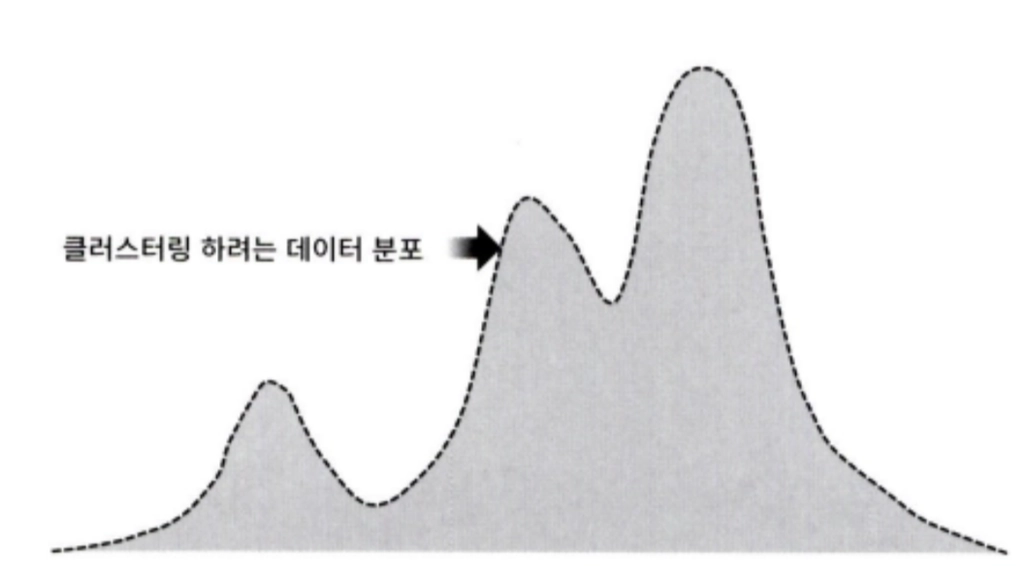

2.  전체 데이터셋은 **서로 다른 정규분포 형태의 확률 분포 곡선**으로 구성되어 있다고 가정한다.

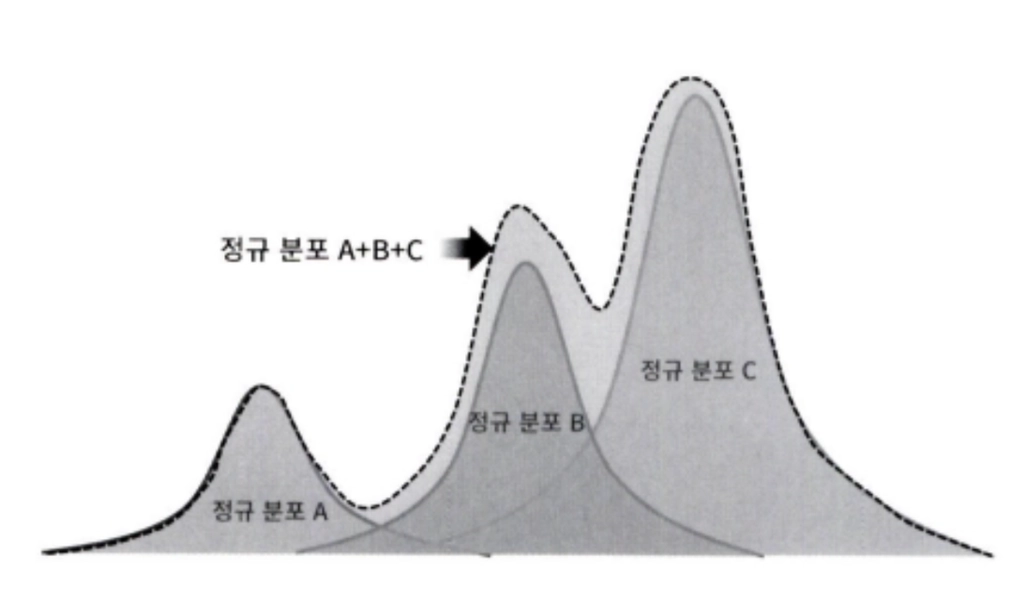

3.  여러 개의 **정규분포 곡선을 추출**하고, 개별 데이터가 어떤 분포에 속하는지 결정한다. 이때 **각각의 분포가 하나의 군집**이 된다.

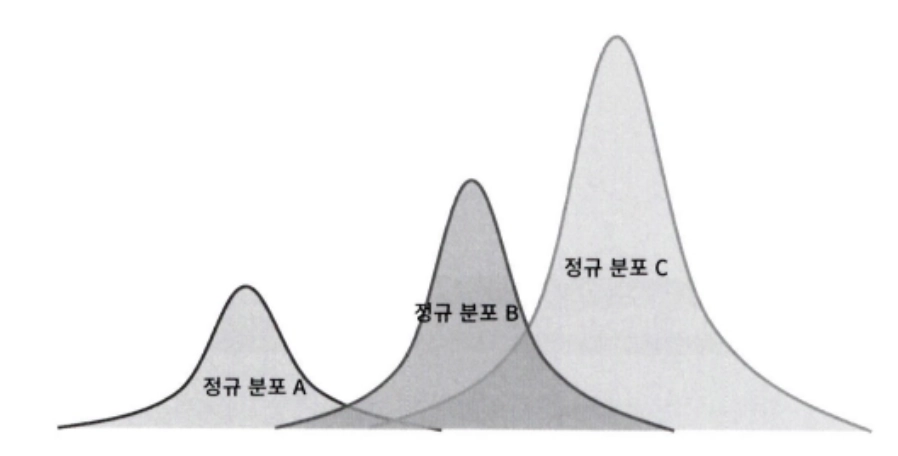

        
### 알고리즘 선택

| 이런 상황이면 | 이걸 쓴다 | 왜 |
| --- | --- | --- |
| **몇 개로 나눠야 할지 감이 안 온다** | 계층적 군집화 | 덴드로그램을 그려놓고 **나중에 자를 위치를 고르면** 됨 |
| **군집이 대체로 동글동글하고 데이터가 크다** | k-means | 빠르고 직관적. 대용량에서도 무리 없음 |
| **군집 모양이 길쭉하거나 서로 겹친다** | GMM | 타원형·중첩 구조를 확률로 처리 |
| **이상치를 골라내는 게 목적이다** | DBSCAN | 이상치에 `-1`을 붙여 **명시적으로 분리** |
| **군집 모양이 초승달·소용돌이처럼 이상하다** | DBSCAN | 모양을 가정하지 않고 밀도로만 판단 |
| **군집마다 밀도가 제각각이다** | HDBSCAN | DBSCAN의 단일 밀도 기준 한계를 보완 |
| **경계에 걸친 데이터의 애매함까지 알고 싶다** | GMM | `predict_proba`로 소속 확률을 반환 |

## 군집화 평가 방법(3. 유효성 검증)

### 외부 평가

- 데이터에 **정답 레이블이 존재하는 경우**에 사용
- **군집화 결과**와 **실제 레이블**을 비교하여 얼마나 유사한지 평가

ex. ARI(Adjusted Rand Index)
- 군집화 결과와 실제 레이블 간의 **일치도**를 측정하는 대표 지표
- 랜드 지수(RI)를 보완해 **우연에 의한 일치 가능성을 배제**한 지표
- **값의 범위**: -1 ~ 1 (일반적으로 0 ~ 1)
    - **1에 가까울수록** 실제 레이블과 거의 완벽하게 일치
    - **0에 가까울수록** 무작위와 유사

### 내부 평가

- **정답 레이블이 없는 경우**에 사용 (군집화에서는 보통 이쪽)
- 군집 내부 **응집도(cohesion)**와 군집 간 **분리도(separation)**를 기반으로 품질을 정량화
    
    → **데이터 자체의 구조를 기반으로 판단**
    
- 알고리즘별 내부 지표 : k-means는 **SSE 최소화**, GMM은 **로그 우도 최대화**
- 범용 지표 : **실루엣 계수**, **던 지수**

#### 실루엣 계수
_클러스터 내 샘플들이 얼마나 조밀하게 모여 있는지를 측정하는 도구_

#### [계산]
$$
s^{(i)} = \frac{b^{(i)} - a^{(i)}}{\max \left\{ b^{(i)}, a^{(i)} \right\}}
$$

1. 샘플 $\mathbf{x}^{(i)}$와 **동일한 클러스터 내** 다른 포인트들과의 평균 거리 → **응집도** $a^{(i)}$
2. 샘플 $\mathbf{x}^{(i)}$와 **가장 가까운 다른 클러스터**의 샘플들과의 평균 거리 → **분리도** $b^{(i)}$
3. 분리도에서 응집도를 뺀 값을 둘 중 큰 값으로 나눔

#### [실루엣 계수 해석]

| 조건 | 계수 값 | 의미 | 평가 |
| --- | --- | --- | --- |
| **분리도 > 응집도** | 1에 가까움 | 자신의 클러스터에 잘 속해 있고, 다른 클러스터와는 멀리 떨어져 있음 | **군집화가 잘 됨** |
| **분리도 = 응집도** | 0에 가까움 | 클러스터 경계에 위치해 군집 간 거리가 모호 | 분리가 명확하지 않음 |
| **분리도 < 응집도** | -1에 가까움 | 잘못된 클러스터에 할당되어 군집이 섞여 있는 상태 | **군집화가 잘못됨** |

#### [코드 실습]

```python
from sklearn.metrics import silhouette_score, silhouette_samples

score = silhouette_score(X_scaled, labels)    # ① 전체 평균
each  = silhouette_samples(X_scaled, labels)  # ② 샘플별 값
```

| 줄 | 이 줄이 하는 일 | 왜 필요한가 |
| --- | --- | --- |
| ① | 모든 샘플의 실루엣 계수 평균을 하나의 숫자로 | **알고리즘끼리 비교**할 때 쓰는 대표값 |
| ② | 샘플 하나하나의 실루엣 계수 배열 | 평균이 같아도 **분포가 고른지**를 봐야 함 (아래 그래프) |

### Dunn Index
_클러스터 간 최소 거리(분리도)와 클러스터 내 최대 거리(응집도)의 비율로 클러스터링 품질을 평가하는 지표_

$$
\text{Dunn Index} = \frac{\min\limits_{i \ne j} \; d(C_i, C_j)}{\max\limits_{1 \le k \le K} \; \delta(C_k)}
$$

- $d(C_i, C_j)$ : 클러스터 $C_i$와 $C_j$ 사이의 거리 (분리도)
- $\delta(C_k)$ : 클러스터 $C_k$ 안에서 가장 멀리 떨어진 두 점 간의 거리 (응집도)

#### [ Dunn Index 해석 ]

- **값이 클수록 좋은 군집화** → 군집 간 거리는 크고(분리도↑), 군집 내부 거리는 작을수록(응집도↑) 좋음
- 0 이상의 값을 가지며 상한은 없음
- **실루엣 계수와 함께 종합적으로 판단**하는 것을 권장

#### [ Dunn Index의 한계 ]

- 군집 수가 많아질수록 계산 비용이 증가
- **극단적인 값**(가장 멀리 떨어진 포인트, 가장 가까운 군집)에 큰 영향을 받음
- 이상치에 민감하게 반응해 수치가 급격히 떨어질 수 있음







































